In [10]:
import copy
import os
import random

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

SEED = 42

# Environment
ON_KAGGLE = False
TARGET_DEVICE = "cuda"
PROJECT_ROOT = "./"

# Training
BATCH_SIZE = 64
NUM_WORKERS = 2

In [26]:
# CLASSIFIER_WEIGHTS_FILE must be a full/absolute path. A relative path would
# resolve differently depending on where the process is run from.
if ON_KAGGLE:
    DATA_PATH = "/kaggle/input/competitions/llm-classification-finetuning"
    CLASSIFIER_WEIGHTS_FILE = "/kaggle/input/models/fernandoquintinojr/deberta-preference-classifier/pytorch/default/1/state_dict.pth"
else:
    DATA_PATH = "./data"
    CLASSIFIER_WEIGHTS_FILE = '/Users/fernandoquintino/Documents/CS files/Kaggle/LLM Classification Finetuning/mlartifacts/3c66a26f08d545db90199be8e6aa11de/artifacts/best_model_state_dict/state_dict.pth'

print(f"Currently {'' if ON_KAGGLE else 'not '}working on Kaggle.")
print("Data location:", DATA_PATH)
print("DATA_PATH exists:", os.path.exists(DATA_PATH))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROJECT_ROOT exists:", os.path.exists(PROJECT_ROOT))
print("CLASSIFIER_WEIGHTS_FILE exists:", os.path.exists(CLASSIFIER_WEIGHTS_FILE))

Currently not working on Kaggle.
Data location: ./data
DATA_PATH exists: True
PROJECT_ROOT: ./
PROJECT_ROOT exists: True
CLASSIFIER_WEIGHTS_FILE exists: True


In [ ]:
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns")
experiment_name = "preference-classifier-local"
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name, artifact_location=f"{PROJECT_ROOT}/mlartifacts")
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location=('/Users/fernandoquintino/Documents/CS files/Kaggle/LLM Classification '
 'Finetuning/mlartifacts'), creation_time=1786656083777, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1786656083777, lifecycle_stage='active', name='preference-classifier-local', tags={}, trace_location=None, workspace='default'>

# Archetecure of model:

### input variables
```
prompt = prompt
response_1 = either reponse_a or response_b
response_2 = the other response_a/b
```
### Encoding model
```
model_1 = DeBERTA v3 base
```

### Classification model
```
model_2 = classification model
```
### pipeline of data
```
prompt -> model_1 -> output_p
response_1 -> model_1 -> output_1
response_2 -> model_1 -> output_2

(output_p, output_1, output_2) -> model_2 -> (prob of first response, prob of second response, prob of tie)
```



In [15]:
class ResponsePreferenceDataset(Dataset):
    """
    A custom Dataset class for handling prompts, responses from two models, and preference labels.
    This Dataset uses lazy loading.
    """

    def __init__(self, prompts, responses_a, responses_b, labels, tokenizer, max_len=512, prob=0.5):
        """
        Initializes the dataset.

        Args:
            prompts (list): A list of strings containing the prompts.
            responses_a (list): A list of strings containing the responses to
                model_a.
            responses_b (list): A list of strings containing the responses to
                model_b.
            labels (ndarray): A 1-d array of integers containing the preferred
                response.
                - 0: response_a preferred
                - 1: response_b preferred
                - 2: tie
            tokenizer (object): An object used to convert text into numerical
                indices.
            max_len (int): The maximum sequence length allowed for each
                prompt/response.
            prob (float): The probability (between 0 and 1) of permuting the
                order of responses.
        """
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.prob = prob
        self.prompts = prompts
        self.responses_a = responses_a
        self.responses_b = responses_b
        self.labels = labels

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        """
        return len(self.prompts)

    def __getitem__(self, idx):
        """
        Retrieves and tokenizes one sample, randomly swaps response_a/b (with
            probability self.prob) to reduce positional bias in training.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            dict: A dictionary containing:
                - prompt (Tensor): Token IDs for the prompt.
                - prompt_mask (Tensor): Attention mask for the prompt.
                - response_0 (Tensor): Token IDs for response_a (possibly
                    swapped).
                - response_0_mask (Tensor): Attention mask for response_0.
                - response_1 (Tensor): Token IDs for response_b (possibly
                    swapped).
                - response_1_mask (Tensor): Attention mask for response_1.
                - label (Tensor): Integer class label 0/1/2,
                    adjusted if swapped.
        """
        prompt = self.prompts[idx]
        label = self.labels[idx]
        response_a = self.responses_a[idx]
        response_b = self.responses_b[idx]

        # Swap responses and adjust label with probability self.prob.
        if random.random() < self.prob:
            response_a, response_b = response_b, response_a
            if label == 0:
                label = 1
            elif label ==1:
                label = 0

        # Switch from response_a/response_b to response_0/response_1 since
        # response_a and response_b may have been swapped.

        response_0, response_1 = response_a, response_b

        encoded_p = self.tokenizer(prompt, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")
        encoded_0 = self.tokenizer(response_0, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")
        encoded_1 = self.tokenizer(response_1, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")

        # After retrieving the tokens, we remove the extra dimension that was added
        # by the tokenizer (the batch dim) even for a single string.
        prompt = encoded_p["input_ids"].squeeze(0)
        response_0 = encoded_0["input_ids"].squeeze(0)
        response_1 = encoded_1["input_ids"].squeeze(0)

        prompt_mask = encoded_p["attention_mask"].squeeze(0)
        response_0_mask = encoded_0["attention_mask"].squeeze(0)
        response_1_mask = encoded_1["attention_mask"].squeeze(0)

        label = torch.tensor(label, dtype=torch.long)

        return {
            "prompt": prompt, "prompt_mask": prompt_mask,
            "response_0": response_0, "response_0_mask": response_0_mask,
            "response_1": response_1, "response_1_mask": response_1_mask,
            "label": label,
            "idx": idx
        }

In [ ]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
#df = df.head(200)

# Convert one hot to 0,1,2
labels_one_hot = df[["winner_model_a","winner_model_b","winner_tie"]]
labels = labels_one_hot.values.argmax(axis = 1)

In [21]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")

In [ ]:
train_df, val_df, train_labels, val_labels = train_test_split(
    df,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_df, test_df, val_labels, test_labels = train_test_split(
    val_df,
    val_labels,
    test_size=0.5,
    stratify=val_labels,
    random_state=SEED
)

trainval_df = pd.concat([train_df, val_df])
trainval_labels = labels[trainval_df.index.values]


In [23]:
full_dataset = ResponsePreferenceDataset(
    prompts=df["prompt"].tolist(),
    responses_a=df["response_a"].tolist(),
    responses_b=df["response_b"].tolist(),
    labels=labels,
    tokenizer=tokenizer,
    prob=0
)

train_dataset = ResponsePreferenceDataset(
    prompts = train_df["prompt"].tolist(),
    responses_a = train_df["response_a"].tolist(),
    responses_b = train_df["response_b"].tolist(),
    labels= train_labels,
    tokenizer = tokenizer
)
val_dataset = ResponsePreferenceDataset(
    prompts = val_df["prompt"].tolist(),
    responses_a = val_df["response_a"].tolist(),
    responses_b = val_df["response_b"].tolist(),
    labels= val_labels,
    tokenizer = tokenizer,
    prob=0
)
test_dataset = ResponsePreferenceDataset(
    prompts = test_df["prompt"].tolist(),
    responses_a = test_df["response_a"].tolist(),
    responses_b = test_df["response_b"].tolist(),
    labels= test_labels,
    tokenizer = tokenizer,
    prob=0
)

In [8]:

full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
train_loader = DataLoader( train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader( val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader( test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

NameError: name 'full_dataset' is not defined

In [25]:
class PreferenceClassifier(nn.Module):
    """
    Classification head that takes pooled encoder representations of the prompt,
    response_0, and response_1 and predicts which response is preferred:
        - 0 response_0 preferred
        - 1 response_1 preferred
        - 2 tie
    """

    def __init__(self, hidden_state=768, num_classes=3):
        """
        Initializes the classifier.

        Args:
            - hidden_state (int): The dimension of the encoding of each text.
            - num_classes (int): The number of classes.
        """
        super().__init__()
        self.fc1 = nn.Linear(hidden_state*3, hidden_state)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(hidden_state, num_classes)

    def forward(self, output_p, output_0, output_1):
        """
        Executes the forward pass of the model to generate classification
        logits.

        Args:
            - output_p (Tensor): Encoded prompt.
            - output_0 (Tensor): Encoded response_0.
            - output_1 (Tensor): Encoded response_1.

        Returns:
            Tensor: Classification logits.
        """
        combined = torch.cat([output_p, output_0, output_1], dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits

In [28]:
class DeepPreferenceClassifier(nn.Module):
    """
    Classification head that takes pooled encoder representations of the prompt,
    response_0, and response_1 and predicts which response is preferred:
        - 0 response_0 preferred
        - 1 response_1 preferred
        - 2 tie
    """

    def __init__(self, hidden_state=768, num_classes=3, num_blocks=2, dropout=0.1):
        """
        Initializes the classifier.

        Args:
            - hidden_state (int): The dimension of the encoding of each text.
            - num_classes (int): The number of classes.
        """
        super().__init__()
        self.fc1 = nn.Linear(hidden_state*3, hidden_state)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_state, hidden_state),
                nn.LayerNorm(hidden_state),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for _ in range(num_blocks)
        ])

        self.fc2 = nn.Linear(hidden_state, num_classes)

    def forward(self, output_p, output_0, output_1):
        """
        Executes the forward pass of the model to generate classification
        logits.

        Args:
            - output_p (Tensor): Encoded prompt.
            - output_0 (Tensor): Encoded response_0.
            - output_1 (Tensor): Encoded response_1.

        Returns:
            Tensor: Classification logits.
        """
        combined = torch.cat([output_p, output_0, output_1], dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)

        for block in self.blocks:
            x = x + block(x)

        logits = self.fc2(x)

        return logits

In [29]:
class PreferenceModel(nn.Module):
    """
    A model that takes the encoder model and the classifier
    model to create the full end-to-end model. The model first encodes prompt,
    response_0, response_1 through the encoder model. The three outputs are fed
    through the classifier model to predict the user preference:
        - 0: response_0 is preferred
        - 1: response_1 is preferred
        - 2: tie
    """

    def __init__(self, model_encoder, model_classifier):
        """
        Initializes the model with the model encoder and model classifier.

        Args:
            model_encoder (nn.Module): A pretrained encoder model
                (e.g. DebertaV2Model) that outputs last_hidden_state given
                input_ids and attention_mask.
            model_classifier (PreferenceClassifier): The classification head
                that takes encoder outputs and predicts preference.
        """
        super().__init__()
        self.model_encoder = model_encoder
        self.model_classifier = model_classifier

    def forward(self,prompt, prompt_mask, response_0, response_0_mask, response_1, response_1_mask):
        """
        Executes the forward pass of the model.

        Args:
            prompt (Tensor): The Input tensor containing token indices of
                prompt.
            prompt_mask (Tensor): Attention mask for the prompt.
            response_0 (Tensor): The Input tensor containing token indices of
                response 0.
            response_0_mask (Tensor): Attention mask for response 0.
            response_1 (Tensor): The Input tensor containing token indices of
                response 1.
            response_1_mask (Tensor): Attention mask for response 1.

        Returns:
            Tensor: Classifier logits.
        """
        output_p = self.model_encoder(input_ids=prompt, attention_mask=prompt_mask).last_hidden_state[:,0,:]
        output_0 = self.model_encoder(input_ids=response_0, attention_mask=response_0_mask).last_hidden_state[:,0,:]
        output_1 = self.model_encoder(input_ids=response_1, attention_mask=response_1_mask).last_hidden_state[:,0,:]

        logits = self.model_classifier(output_p, output_0, output_1)

        return logits

In [ ]:
# Testing PreferenceModel:
model_encoder = AutoModel.from_pretrained("microsoft/deberta-v3-small", torch_dtype=torch.float32)
model_classifier =DeepPreferenceClassifier(num_blocks=3)
model_classifier.load_state_dict(torch.load(CLASSIFIER_WEIGHTS_FILE))
model = PreferenceModel(model_encoder,model_classifier)

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 165.66it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok

### Intial run. Time with calling encoder 3 separate times:
100%|██████████| 180/180 [13:00<00:00,  4.34s/it]
Intitial test accuracy before training: 30.880306193458594

Note:
- adding workers didn't speed up time
- changed from calling encoder 3 times into one time by stacking into one big batch. Didn't improve by much (30 seconds per batch)
- Considered changing max_len on token lengths, but stats on data shows we would lose too much info:

prompt: mean=101.0, median=27,  95th=377, 99th=1390, max=9358
response_a: mean=347.0, median=264,  95th=963, 99th=1961, max=9557
response_b: mean=350.6, median=266,  95th=960, 99th=2014, max=15685

Note:
 - Tried mixed precision and got:
 100%|██████████| 180/180 [05:35<00:00,  1.87s/it]Intitial test accuracy before training: 34.8990953375087
 - Mixed precission and "small" version of model:
 100%|██████████| 180/180 [02:39<00:00,  1.13it/s]Intitial test accuracy before training: 30.897703549060545
 - Mixed precission and "xsmall":
 100%|██████████| 180/180 [02:37<00:00,  1.14it/s]Intitial test accuracy before training: 34.49895615866388

In [ ]:
def train_epoch(model, loader, device, optimizer, loss):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        batch = {k:v.to(device) for k,v in batch.items()}

        optimizer.zero_grad()

        output = model(batch["prompt"],
                       batch["prompt_mask"],
                       batch["response_0"],
                       batch["response_0_mask"],
                       batch["response_1"],
                       batch["response_1_mask"]
        )

        batch_loss = loss(output, batch["label"])
        batch_loss.backward()
        optimizer.step()

        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output,1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = (correct/ total) * 100

    return epoch_loss, epoch_acc


def validate_epoch(model, loader, device, optimizer, loss):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        batch = {k:v.to(device) for k,v in batch.items()}

        output = model(batch["prompt"],
                       batch["prompt_mask"],
                       batch["response_0"],
                       batch["response_0_mask"],
                       batch["response_1"],
                       batch["response_1_mask"]
        )

        batch_loss = loss(output, batch["label"])

        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output,1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = (correct/ total) * 100

    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, device, optimizer, loss, num_epochs, run_name=None, scheduler=None):

    loss_train_history = []
    acc_train_history = []
    loss_val_history = []
    acc_val_history = []

    best_model = copy.deepcopy(model)
    best_acc = 0.0

    ######################
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param("learning_rate", optimizer.param_groups[0]["lr"])
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("optimizer_type", type(optimizer).__name__)
        if scheduler is not None:
            mlflow.log_param("scheduler_type", type(scheduler).__name__)
            mlflow.log_params(scheduler.state_dict())

        mlflow.log_param("model_type", type(model).__name__)
        if hasattr(model, "blocks"):
            mlflow.log_param("num_blocks", len(model.blocks))

        print(f"Training on device {device} for {num_epochs} epochs:")
        model = model.to(device)
        epoch_bar = tqdm(range(num_epochs), desc="Epochs")
        for epoch in epoch_bar:
            epoch_train_loss, epoch_train_acc = train_epoch(model, train_loader, device, optimizer, loss)
            loss_train_history.append(epoch_train_loss)
            acc_train_history.append(epoch_train_acc)

            epoch_val_loss, epoch_val_acc = validate_epoch(model, val_loader, device, optimizer, loss)
            loss_val_history.append(epoch_val_loss)
            acc_val_history.append(epoch_val_acc)

            mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
            mlflow.log_metric("train_acc", epoch_train_acc, step=epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
            mlflow.log_metric("val_acc", epoch_val_acc, step=epoch)
            mlflow.log_metric("learning_rate", optimizer.param_groups[0]["lr"], step=epoch)

            if scheduler is not None:
                scheduler.step(epoch_val_loss)

            epoch_bar.set_description(f"Epoch {epoch+1} | Train loss: {epoch_train_loss:.4f} acc: {epoch_train_acc:.2f}%"
                                    f"| Val loss: {epoch_val_loss:.4f} acc: {epoch_val_acc:.2f}%")
            if epoch_val_acc > best_acc:
                best_model = copy.deepcopy(model)
                best_acc = epoch_val_acc

        mlflow.log_metric("best_val_acc", best_acc)
        mlflow.pytorch.log_state_dict(best_model.state_dict(), artifact_path="best_model_state_dict")

    ##############################################
    print(f"Training Complete. Best Val ACC: {best_acc}")

    return {
        "loss_train_history": loss_train_history,
        "acc_train_history": acc_train_history,
        "loss_val_history": loss_val_history,
        "acc_val_history": acc_val_history,
        "best_acc": best_acc,
        "best_model": best_model
    }

In [44]:
device = torch.device('cuda' if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu"
)
print(f"Using {device}")

Using mps


In [48]:
loss = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

In [ ]:
if device.type == TARGET_DEVICE:
    model = model.to(device)
    print(validate_epoch(model,val_loader, device, optimizer, loss))
else:
    print(f"Device is set to {device}. Needs to be set to {TARGET_DEVICE}.")

Device is set to mps. Needs to be set to cuda.


In [ ]:
run_name = None

if device.type == TARGET_DEVICE and run_name is not None:
    results = train_model(model=model,
                          train_loader=train_loader,
                          val_loader=val_loader,
                          device=device,
                          optimizer=optimizer,
                          loss=loss,
                          num_epochs=160,
                          scheduler=scheduler,
                          run_name=run_name
    )
else:
    print(f"Device is set to {device} (Needs to be set to {TARGET_DEVICE}).")

Device is set to mps (Needs to be set to cuda).


In [52]:
runs = mlflow.search_runs(experiment_names=["preference-classifier-local"])
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.learning_rate,metrics.val_acc,metrics.train_acc,...,params.cooldown_counter,params.batch_size,params.min_lrs,params._last_lr,params.patience,params.threshold_mode,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
0,c4f3ae2518634e78bd42e3b9d8054880,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-19 16:01:18.565000+00:00,2026-08-19 16:05:27.338000+00:00,1.031180,1.525879e-08,47.077244,47.336944,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 3 blocks with scheduler,NOTEBOOK
1,f7e93ccf74f14bfbb53933e86654397d,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 21:12:37.243000+00:00,2026-08-14 21:15:07.573000+00:00,1.043657,3.125000e-05,46.711900,46.132098,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 16 blocks with scheduler,NOTEBOOK
2,d2d233df96d848cb9bfb7b77714b011a,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 21:04:14.388000+00:00,2026-08-14 21:09:04.286000+00:00,1.031154,1.562500e-05,47.199026,47.345643,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 14 blocks with scheduler,NOTEBOOK
3,5794103658ca4c2eb8cba37fb22698e4,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 21:00:18.207000+00:00,2026-08-14 21:04:14.351000+00:00,1.031946,3.906250e-06,47.268615,47.186882,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 12 blocks with scheduler,NOTEBOOK
4,9be2d75a4e5c4db58fa3d57a6a3cf615,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 20:51:27.243000+00:00,2026-08-14 20:54:27.396000+00:00,1.036917,1.220703e-07,46.885873,46.723647,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 8 blocks with scheduler,NOTEBOOK
5,b8042821041a4d1188d2d0216aadb0d1,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 20:48:57.130000+00:00,2026-08-14 20:51:27.195000+00:00,1.032575,9.765625e-07,47.129436,47.132511,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classifier 6 blocks with scheduler,NOTEBOOK
6,3c66a26f08d545db90199be8e6aa11de,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 20:38:24.392000+00:00,2026-08-14 20:40:25.047000+00:00,1.028690,1.562500e-05,47.320807,47.395663,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,Deep Classfier 3 blocks with scheduler,NOTEBOOK
7,22a163fa22fb495ba723212af0dffcad,2,FAILED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 20:35:55.972000+00:00,2026-08-14 20:35:59.001000+00:00,NaN,NaN,NaN,NaN,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,reduce_lr_plateau,NOTEBOOK
8,ff8dec6868d84bd7a3ad01e98e4d246c,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 19:59:05.572000+00:00,2026-08-14 20:00:33.674000+00:00,1.034732,1.953125e-06,46.621556,46.972260,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,kfold_4,NOTEBOOK
9,7759f0738bbd449787f037b9771ed382,2,FINISHED,/Users/fernandoquintino/Documents/CS files/Kag...,2026-08-14 19:57:39.735000+00:00,2026-08-14 19:59:05.544000+00:00,1.033936,1.953125e-06,46.037116,47.048305,...,0,512,[0],[0.001],3,rel,fernandoquintino,LLM_kaggle_proect.ipynb,kfold_3,NOTEBOOK


In [ ]:
filename = f"model_classifier Val Acc {results["best_acc"]}.pt"
torch.save(
    results["best_model"].state_dict(),
    os.path.join(PROJECT_ROOT,filename)
)

In [32]:
def plot_results(results):
    epochs = range(1, len(results["loss_train_history"]) + 1)

    # Loss history
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(epochs, results["loss_train_history"], marker="o", color="blue", label="Train")
    ax.plot(epochs, results["loss_val_history"], marker="o", color="red", label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss per Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

    # Accuracy History
    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.plot(epochs, results["acc_train_history"], marker="o", color="blue", label="Train")
    ax.plot(epochs, results["acc_val_history"], marker="o", color="red", label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accracy per Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

#epochs = range(1, len(results["loss_train_history"]) + 1)

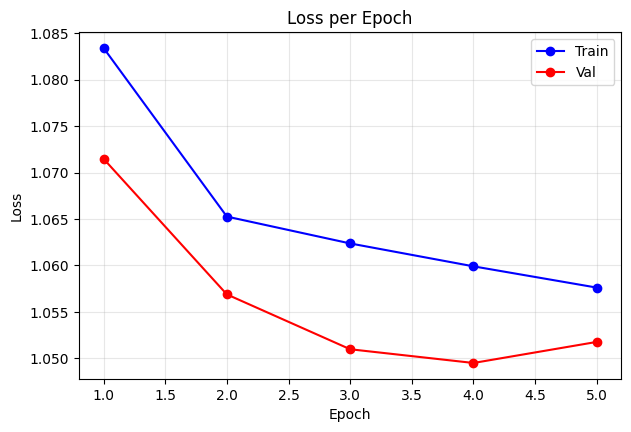

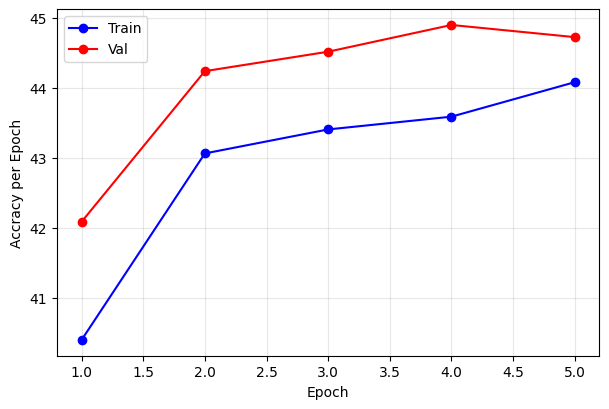

In [31]:
plot_results(results)